# Trial ResNet Places365 untuk Deteksi Scene

Notebook ini memakai ResNet Places365 untuk mendeteksi jenis scene pada `dataset/images/1.jpg`.

Berbeda dari CLIP yang membandingkan gambar dengan label buatan kita, Places365 memakai 365 kelas scene bawaan seperti `beach`, `coast`, `lagoon`, `forest`, `mountain`, `restaurant`, dan scene lain.

In [7]:
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image

IMAGE_PATH = Path("dataset/images/139.jpg")
MODEL_DIR = Path("models")
CATEGORIES_PATH = MODEL_DIR / "categories_places365.txt"

# Kalau resnet50 sudah ada, notebook otomatis pakai resnet50.
# Kalau belum ada, default trial memakai resnet18 karena lebih ringan.
ARCH = "resnet50" if (MODEL_DIR / "resnet50_places365.pth.tar").exists() else "resnet18"
MODEL_PATH = MODEL_DIR / f"{ARCH}_places365.pth.tar"

# True = unduh file model/kategori jika belum ada di folder models.
AUTO_DOWNLOAD = True
TOP_K = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_URLS = {
    "resnet18": "http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar",
    "resnet50": "http://places2.csail.mit.edu/models_places365/resnet50_places365.pth.tar",
}
CATEGORY_URLS = [
    "https://raw.githubusercontent.com/csailvision/places365/master/categories_places365.txt",
]

print(f"Arsitektur: {ARCH}")
print(f"Device: {DEVICE}")
print(f"Image path: {IMAGE_PATH.resolve()}")
print(f"Model path: {MODEL_PATH.resolve()}")

Arsitektur: resnet18
Device: cpu
Image path: C:\Users\elsae\.vscode\Documents\city-branding-multimodal\dataset\images\139.jpg
Model path: C:\Users\elsae\.vscode\Documents\city-branding-multimodal\models\resnet18_places365.pth.tar


In [8]:
def download_if_missing(path: Path, urls: list[str]) -> None:
    if path.exists():
        print(f"Sudah ada: {path}")
        return

    if not AUTO_DOWNLOAD:
        raise FileNotFoundError(f"File belum ada: {path}")

    path.parent.mkdir(parents=True, exist_ok=True)
    last_error = None

    for url in urls:
        try:
            print(f"Mengunduh {path.name} dari {url}")
            urlretrieve(url, path)
            print(f"Selesai: {path}")
            return
        except (URLError, OSError) as exc:
            last_error = exc
            print(f"Gagal dari URL ini: {exc}")

    raise RuntimeError(f"Tidak bisa mengunduh {path.name}. Cek koneksi internet.") from last_error


download_if_missing(CATEGORIES_PATH, CATEGORY_URLS)
download_if_missing(MODEL_PATH, [MODEL_URLS[ARCH]])

Sudah ada: models\categories_places365.txt
Sudah ada: models\resnet18_places365.pth.tar


In [9]:
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1, base_width=64, dilation=1, norm_layer=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock hanya mendukung groups=1 dan base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 belum didukung untuk BasicBlock")

        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1, base_width=64, dilation=1, norm_layer=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups

        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=365, groups=1, width_per_group=64, replace_stride_with_dilation=None, norm_layer=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer
        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            replace_stride_with_dilation = [False, False, False]
        self.groups = groups
        self.base_width = width_per_group

        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = [
            block(
                self.inplanes,
                planes,
                stride,
                downsample,
                self.groups,
                self.base_width,
                previous_dilation,
                norm_layer,
            )
        ]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups, base_width=self.base_width, dilation=self.dilation, norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def build_resnet_places365(arch: str) -> nn.Module:
    if arch == "resnet18":
        return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=365)
    if arch == "resnet50":
        return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=365)
    raise ValueError("ARCH harus 'resnet18' atau 'resnet50'")

In [10]:
def load_categories(path: Path) -> list[str]:
    categories = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        raw_name = line.split()[0]
        scene_name = raw_name.split("/")[-1].replace("_", " ")
        categories.append(scene_name)
    return categories


def clean_state_dict(checkpoint):
    state_dict = checkpoint.get("state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    cleaned = {}
    for key, value in state_dict.items():
        key = key.replace("module.", "")
        cleaned[key] = value
    return cleaned


categories = load_categories(CATEGORIES_PATH)
if len(categories) != 365:
    raise ValueError(f"Jumlah kategori harus 365, tetapi terbaca {len(categories)}")

model = build_resnet_places365(ARCH)
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(clean_state_dict(checkpoint), strict=True)
model = model.to(DEVICE)
model.eval()

print(f"Model {ARCH} Places365 siap dipakai.")
print(f"Jumlah kategori scene: {len(categories)}")

Model resnet18 Places365 siap dipakai.
Jumlah kategori scene: 365


In [11]:
BICUBIC = Image.Resampling.BICUBIC if hasattr(Image, "Resampling") else Image.BICUBIC
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def resize_for_places365(image: Image.Image, size: int = 256) -> Image.Image:
    return image.resize((size, size), BICUBIC)


def center_crop(image: Image.Image, size: int = 224) -> Image.Image:
    width, height = image.size
    left = max((width - size) // 2, 0)
    top = max((height - size) // 2, 0)
    return image.crop((left, top, left + size, top + size))


def preprocess_image(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path).convert("RGB")
    image = resize_for_places365(image, 256)
    image = center_crop(image, 224)

    array = np.asarray(image).astype("float32") / 255.0
    tensor = torch.from_numpy(array).permute(2, 0, 1)
    tensor = (tensor - IMAGENET_MEAN) / IMAGENET_STD
    return tensor.unsqueeze(0)


@torch.no_grad()
def predict_scene_places365(image_path: Path, top_k: int = 10) -> pd.DataFrame:
    input_tensor = preprocess_image(image_path).to(DEVICE)
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)[0]
    top_probabilities, top_indices = probabilities.topk(top_k)

    rows = []
    for rank, (probability, index) in enumerate(zip(top_probabilities, top_indices), start=1):
        idx = int(index.item())
        rows.append(
            {
                "rank": rank,
                "scene": categories[idx],
                "probability": float(probability.item()),
                "score_logit": float(logits[0, idx].item()),
            }
        )

    return pd.DataFrame(rows)

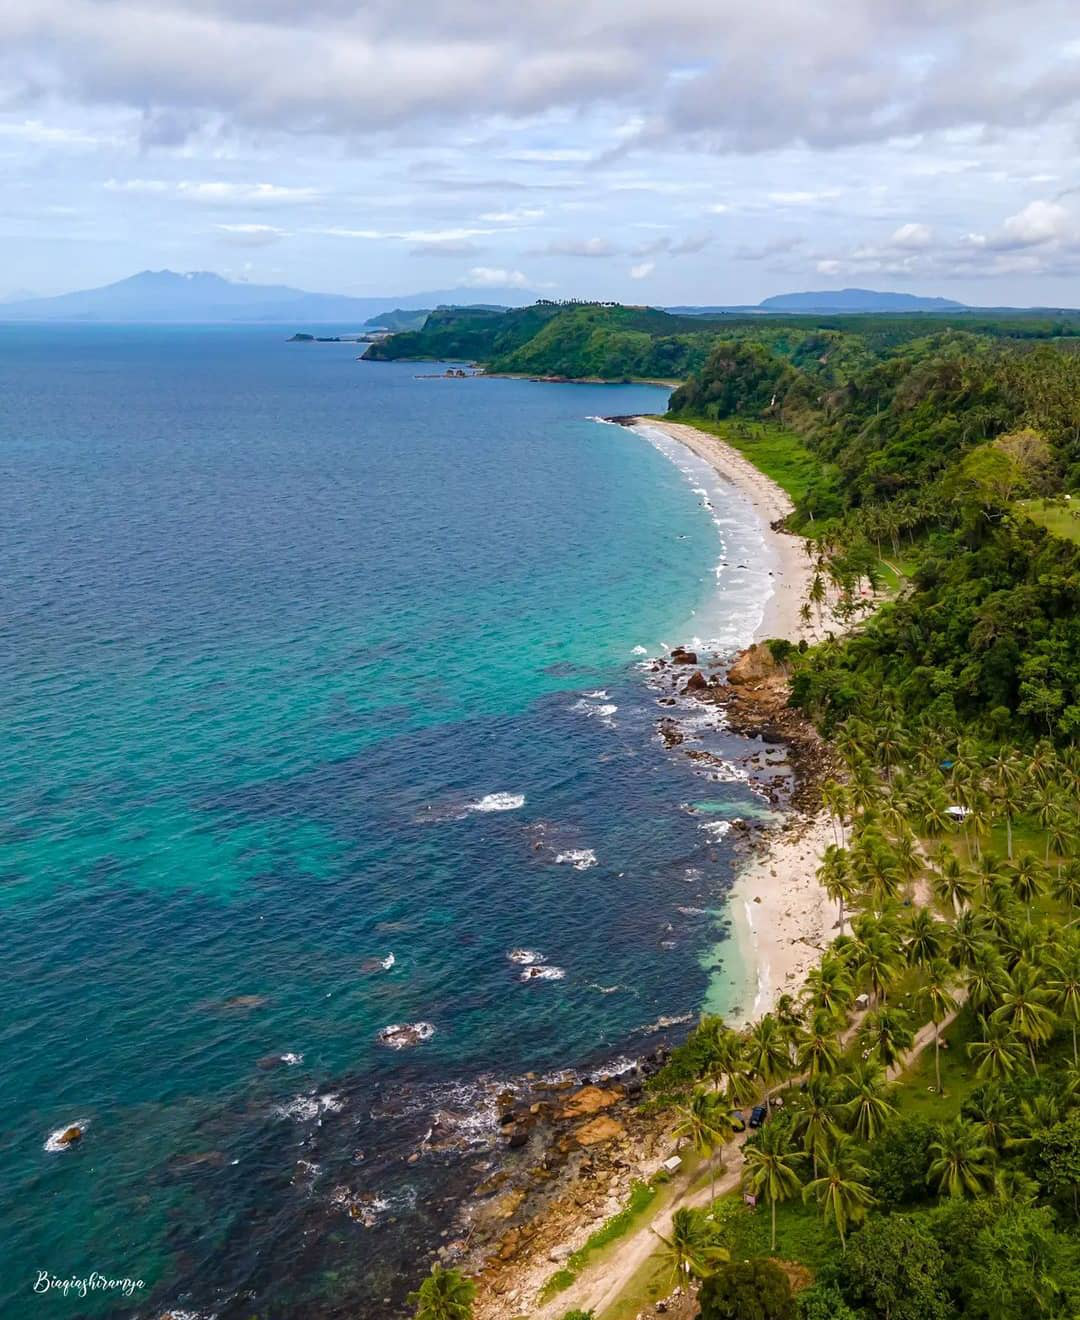

Scene yang terdeteksi oleh ResNet Places365:


,rank,scene,probability,score_logit
0,1,cliff,47.27%,11.79
1,2,coast,25.67%,11.18
2,3,lagoon,7.85%,10.00
3,4,ocean,7.03%,9.89
4,5,beach,2.86%,8.99
5,6,islet,2.63%,8.90
6,7,valley,0.99%,7.92
7,8,river,0.79%,7.71
8,9,wave,0.68%,7.56
9,10,harbor,0.44%,7.13


Ringkasan scene teratas:
cliff (47.27%), coast (25.67%), lagoon (7.85%), ocean (7.03%), beach (2.86%), islet (2.63%), valley (0.99%), river (0.79%), wave (0.68%), harbor (0.44%)


In [12]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH.resolve()}")

image = Image.open(IMAGE_PATH).convert("RGB")
display(image)

scene_results = predict_scene_places365(IMAGE_PATH, top_k=TOP_K)

print("Scene yang terdeteksi oleh ResNet Places365:")
display(scene_results.style.format({"probability": "{:.2%}", "score_logit": "{:.2f}"}))

print("Ringkasan scene teratas:")
print(", ".join(f"{row.scene} ({row.probability:.2%})" for row in scene_results.itertuples(index=False)))